# Top 5 Bonos Argentinos en USD — Mayor volumen operado

## Fuente: https://data912.com/live/arg_bonds

Text(0.13, 1.01, 'Top 5 Bonos en USD — Mayor volumen operado')

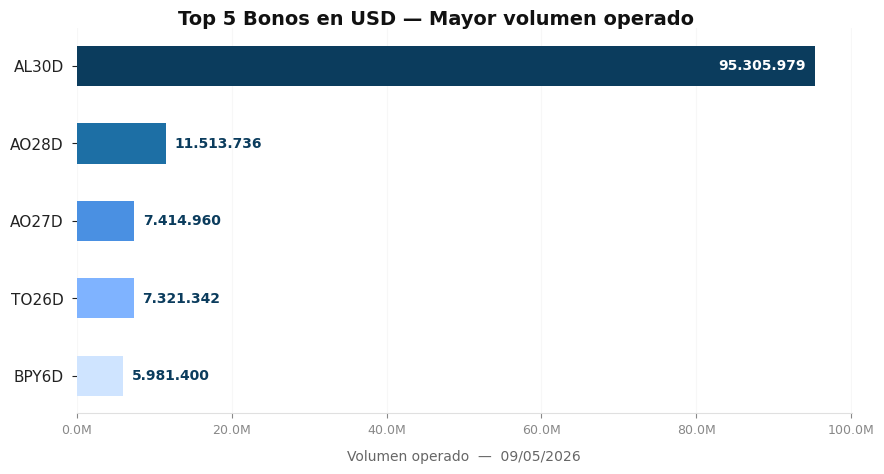

In [9]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

# ── Estilo
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#e0e0e0",
    "axes.labelcolor":   "#444444",
    "xtick.color":       "#888888",
    "ytick.color":       "#222222",
    "text.color":        "#222222",
    "grid.color":        "#f0f0f0",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
})

PALETTE   = ["#CFE4FF", "#7FB3FF", "#4A90E2", "#1D6FA5", "#0B3C5D"]
MOCK      = False
URL       = "https://data912.com/live/arg_bonds"

# ── Datos
def fetch_data() -> pd.DataFrame:
    global MOCK
    try:
        resp = requests.get(URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
        resp.raise_for_status()
        raw = resp.json()
        MOCK = False
    except Exception as e:
        print(f"⚠️  API falló ({e}). Usando dataset mock.")
        MOCK = True
        raw = [
            {"symbol": "AL30D", "c": 68.5, "pct_change":  2.4, "v": 5_200_000},
            {"symbol": "GD30D", "c": 71.0, "pct_change":  3.1, "v": 8_400_000},
            {"symbol": "AL35D", "c": 55.2, "pct_change":  1.8, "v": 3_100_000},
            {"symbol": "GD35D", "c": 58.3, "pct_change": -0.5, "v": 2_900_000},
            {"symbol": "AL29D", "c": 79.4, "pct_change":  0.9, "v": 4_600_000},
        ]

    df = pd.DataFrame(raw)
    df = df[df["symbol"].str.endswith("D", na=False)].copy()
    df["v"] = pd.to_numeric(df.get("v", 0), errors="coerce").fillna(0)
    df["c"] = pd.to_numeric(df["c"],        errors="coerce")
    df = df.dropna(subset=["c"]).query("c > 0").reset_index(drop=True)
    return df


df = fetch_data()

# Ordenar ascendente
top_vol = df.nlargest(5, "v").sort_values("v").reset_index(drop=True)

# ── Gráfico
today      = datetime.now().strftime("%d/%m/%Y")
mock_label = "  ⚠ DATOS MOCK" if MOCK else ""

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")

bars = ax.barh(top_vol["symbol"], top_vol["v"],
               color=PALETTE,        # índice 0 = menor, 4 = mayor
               height=0.52, edgecolor="none", zorder=3)

max_v = top_vol["v"].max()
for bar, val, color in zip(bars, top_vol["v"], PALETTE):
    label = f"{val:,.0f}".replace(",", ".")
    # Color del texto: oscuro para barras claras, blanco para barras oscuras
    txt_color = "#0B3C5D" if val < max_v * 0.5 else "white"
    # Intentar poner el texto dentro; si la barra es muy corta, afuera
    bar_width = bar.get_width()
    if bar_width > max_v * 0.25:
        ax.text(bar_width - max_v * 0.012,
                bar.get_y() + bar.get_height() / 2,
                label, va="center", ha="right",
                fontsize=10, color=txt_color, fontweight="bold")
    else:
        ax.text(bar_width + max_v * 0.012,
                bar.get_y() + bar.get_height() / 2,
                label, va="center", ha="left",
                fontsize=10, color="#0B3C5D", fontweight="bold")

ax.set_xlabel(f"Volumen operado  —  {today}", fontsize=10, labelpad=10, color="#666666")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)
ax.grid(axis="x", alpha=0.5, zorder=0)
ax.tick_params(axis="y", labelsize=11, pad=6)
ax.tick_params(axis="x", labelsize=9)
ax.set_axisbelow(True)

# Título y subtítulo
fig.text(0.13, 1.01,
         f"Top 5 Bonos en USD — Mayor volumen operado{mock_label}",
         fontsize=14, fontweight="bold", color="#111111",
         transform=ax.transAxes)